# EDA — Dataset phát hiện rau củ quả (subset COCO 2017)

Notebook này phân tích dataset đã dựng ở bước 2, gồm 5 lớp: `apple`, `banana`,
`broccoli`, `carrot`, `orange`.

Mục tiêu của phân tích không phải là mô tả dữ liệu cho đủ mục, mà là trả lời
trước ba câu hỏi sẽ quyết định cách đọc kết quả ở bước so sánh model:

1. Dữ liệu có cân bằng giữa các lớp và giữa các split không? Nếu không, mAP
   trung bình sẽ bị lớp nào chi phối?
2. Vật thể trong dataset to hay nhỏ? Đây là yếu tố quan trọng nhất, vì
   SSDlite320 resize ảnh về 320×320 và không có FPN, nên nó sẽ mất nhiều thông
   tin ở vật thể nhỏ hơn D-FINE và YOLOv8 (cả hai chạy 640×640).
3. Cảnh có đông và chồng lấn không? Mức chồng lấn cao gây khó cho bước NMS và
   ảnh hưởng trực tiếp tới recall.

Toàn bộ notebook chỉ đọc 3 file annotation JSON (tổng khoảng 5.7 MB), không đọc
1.13 GB ảnh, nên chạy xong trong vài chục giây trên CPU.

## 0. Chuẩn bị

In [1]:
import sys
from pathlib import Path

# Tìm thư mục gốc dự án. Hoạt động cả khi chạy local lẫn khi upload lên
# Kaggle/Colab (khi đó notebook nằm ở chỗ khác so với package src/).
def find_project_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for extra in (Path("/kaggle/working"), Path("/kaggle/input"), Path("/content")):
        if extra.exists():
            candidates.append(extra)
            candidates.extend(p for p in extra.iterdir() if p.is_dir())
    for c in candidates:
        if (c / "src" / "config.py").is_file():
            return c
    raise RuntimeError("Khong tim thay thu muc goc du an (can co src/config.py)")

PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))
print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = C:\Users\KUONG\Desktop\final-object-detection


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import (
    AXIS_LINE, CLASS_COLORS_HEX, CLASSES, FIGURES_DIR, GRIDLINE,
    INK_MUTED, INK_PRIMARY, INK_SECONDARY, RESULTS_DIR, SEQUENTIAL_RAMP,
    SPLITS, SURFACE,
)
from src.data.eda import cooccurrence, load_all, pairwise_iou_per_image

# Style dùng chung cho mọi hình, để các hình trong báo cáo nhìn thống nhất.
mpl.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": AXIS_LINE,
    "axes.labelcolor": INK_SECONDARY,
    "axes.titlecolor": INK_PRIMARY,
    "axes.titlelocation": "left",
    "axes.titleweight": "bold",
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRIDLINE,
    "grid.linewidth": 0.8,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "text.color": INK_PRIMARY,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "font.size": 10,
    "axes.titlesize": 11.5,
    "figure.dpi": 110,
})

CLASS_COLORS = [CLASS_COLORS_HEX[c] for c in CLASSES]
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# matplotlib 3.11 thay tham số `vert` của boxplot bằng `orientation`.
# Máy local dùng 3.11, còn Colab/Kaggle thường còn 3.10, nên chọn theo version.
_MPL = tuple(int(p) for p in mpl.__version__.split(".")[:2])
BOX_HORIZONTAL = {"orientation": "horizontal"} if _MPL >= (3, 11) else {"vert": False}

def save_fig(fig, name):
    path = FIGURES_DIR / f"eda_{name}.png"
    fig.savefig(path, dpi=140, bbox_inches="tight", facecolor=SURFACE)
    print("saved:", path.name)

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

In [3]:
images_df, anns_df = load_all()
print(f"images_df : {images_df.shape[0]:,} dòng  |  cột: {list(images_df.columns)}")
print(f"anns_df   : {anns_df.shape[0]:,} dòng")
anns_df.head(3)

images_df : 7,137 dòng  |  cột: ['image_id', 'file_name', 'img_w', 'img_h', 'split', 'n_objects', 'n_classes', 'n_crowd', 'img_area', 'img_aspect']
anns_df   : 38,460 dòng


,ann_id,image_id,category_id,area,iscrowd,segmentation,split,class,x,y,w,h,img_w,img_h,box_area,img_area,rel_area,rel_size,aspect,size_bucket,cx_norm,cy_norm
0,1,9,3,77504.10,0,[],train,broccoli,249.60,229.27,316.24,245.08,640,480,77504.0992,307200,0.252292,0.502287,1.290354,large,0.637063,0.732938
1,2,9,5,3515.34,0,[],train,orange,376.20,40.36,75.55,46.53,640,480,3515.3415,307200,0.011443,0.106973,1.623684,medium,0.646836,0.132552
2,3,9,5,2710.13,0,[],train,orange,465.78,38.97,58.07,46.67,640,480,2710.1269,307200,0.008822,0.093926,1.244268,medium,0.773148,0.129802


## 1. Tổng quan theo split

`train` và `val` được tách ra từ `train2017`. `test` lấy nguyên từ `val2017`,
là tập ảnh model chưa từng thấy trong quá trình huấn luyện.

In [4]:
overview = (
    images_df.groupby("split", observed=True)
    .agg(
        so_anh=("image_id", "size"),
        so_instance=("n_objects", "sum"),
        vat_the_tren_anh=("n_objects", "mean"),
        trung_vi_vat_the=("n_objects", "median"),
        so_lop_tb=("n_classes", "mean"),
    )
    .round(2)
)
overview["ty_le_anh_%"] = (
    100 * overview["so_anh"] / overview["so_anh"].sum()
).round(1)
overview

,so_anh,so_instance,vat_the_tren_anh,trung_vi_vat_the,so_lop_tb,ty_le_anh_%
split,,,,,,
train,5803,31389,5.41,3.0,1.34,81.3
val,1024,5479,5.35,3.0,1.34,14.3
test,310,1592,5.14,3.0,1.34,4.3


Nhận xét: số vật thể trung bình trên mỗi ảnh ở cả ba split đều xấp xỉ 5.2–5.4.
Đây là mức khá cao — nghĩa là bài toán không phải "một ảnh một vật thể" mà là
phát hiện nhiều vật thể cùng loại trong một khung hình. Điều này phù hợp với
mục tiêu ứng dụng là **đếm** số lượng nông sản.

Tập `test` chỉ có 310 ảnh. Con số này nhỏ, nên các chỉ số mAP trên test sẽ có
sai số thống kê đáng kể. Cần nêu rõ giới hạn này trong báo cáo, và khi hai model
chênh nhau dưới khoảng 1–2 điểm mAP thì không nên kết luận model này tốt hơn
model kia.

## 2. Phân bố theo lớp

Hai cách đếm cho hai thông tin khác nhau:

- **Số instance**: quyết định lớp nào chi phối hàm loss khi huấn luyện.
- **Số ảnh**: quyết định model nhìn thấy lớp đó trong bao nhiêu bối cảnh khác nhau.

In [5]:
inst_per_class = anns_df.groupby("class").size().reindex(CLASSES)
img_per_class = (
    anns_df.drop_duplicates(["image_id", "class"])
    .groupby("class").size().reindex(CLASSES)
)

class_table = pd.DataFrame({
    "so_instance": inst_per_class,
    "so_anh": img_per_class,
    "instance_tren_anh": (inst_per_class / img_per_class).round(2),
})
class_table["ty_le_instance_%"] = (
    100 * class_table["so_instance"] / class_table["so_instance"].sum()
).round(1)
class_table.sort_values("so_instance", ascending=False)

,so_instance,so_anh,instance_tren_anh,ty_le_instance_%
class,,,,
banana,9837,2346,4.19,25.6
carrot,8223,1764,4.66,21.4
broccoli,7624,2010,3.79,19.8
orange,6686,1784,3.75,17.4
apple,6090,1662,3.66,15.8


saved: eda_01_class_distribution.png


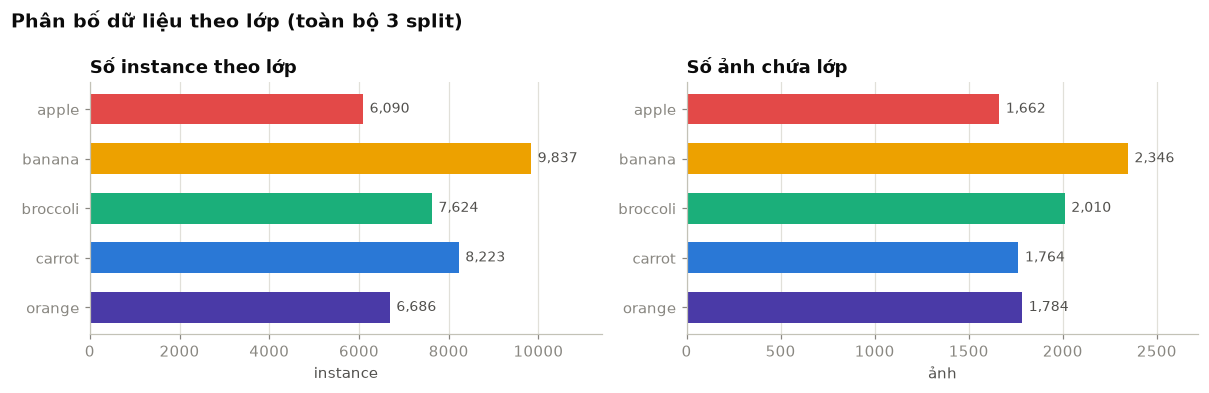

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

for ax, series, title, xlabel in [
    (axes[0], inst_per_class, "Số instance theo lớp", "instance"),
    (axes[1], img_per_class, "Số ảnh chứa lớp", "ảnh"),
]:
    y = np.arange(len(CLASSES))
    ax.barh(y, series.values, color=CLASS_COLORS, height=0.62)
    ax.set_yticks(y, CLASSES)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(axis="y", visible=False)
    ax.set_xlim(0, series.max() * 1.16)
    # Ghi số trực tiếp lên bar: hai màu (banana, broccoli) có độ tương phản
    # dưới 3:1 trên nền trắng nên không được để màu tự mang thông tin.
    for yi, v in zip(y, series.values):
        ax.text(v + series.max() * 0.015, yi, f"{v:,}", va="center",
                fontsize=9, color=INK_SECONDARY)

fig.suptitle("Phân bố dữ liệu theo lớp (toàn bộ 3 split)", x=0.005, ha="left",
             fontsize=12.5, fontweight="bold")
fig.tight_layout()
save_fig(fig, "01_class_distribution")
plt.show()

In [7]:
imbalance = inst_per_class.max() / inst_per_class.min()
print(f"Tỷ lệ mất cân bằng (lớp nhiều nhất / lớp ít nhất): {imbalance:.2f}x")
print(f"  nhiều nhất: {inst_per_class.idxmax()} ({inst_per_class.max():,} instance)")
print(f"  ít nhất   : {inst_per_class.idxmin()} ({inst_per_class.min():,} instance)")

Tỷ lệ mất cân bằng (lớp nhiều nhất / lớp ít nhất): 1.62x
  nhiều nhất: banana (9,837 instance)
  ít nhất   : apple (6,090 instance)


Mức mất cân bằng khoảng 1.6 lần là **nhẹ**. Để so sánh, các dataset thực tế
thường mất cân bằng 10–100 lần. Với mức này:

- Không cần dùng các kỹ thuật xử lý mất cân bằng như focal loss có trọng số hay
  oversampling.
- mAP trung bình (mAP@[.5:.95] trên toàn bộ lớp) là chỉ số đáng tin, không bị
  một lớp duy nhất chi phối.
- Tuy nhiên vẫn nên báo cáo thêm **mAP theo từng lớp**, vì độ khó của các lớp
  khác nhau (xem phần 4 về kích thước vật thể).

`banana` có nhiều instance nhất nhưng số instance trên mỗi ảnh chỉ ở mức trung
bình, nghĩa là nó xuất hiện ở nhiều ảnh khác nhau. Ngược lại, lớp nào có
`instance_tren_anh` cao là lớp thường xuất hiện theo cụm.

## 3. Tính nhất quán giữa các split

Nếu phân bố lớp lệch giữa train và test thì điểm số trên test không phản ánh
đúng năng lực model. Ba biểu đồ dưới đây dùng chung thang đo để so sánh trực tiếp.

saved:

 eda_02_class_share_by_split.png


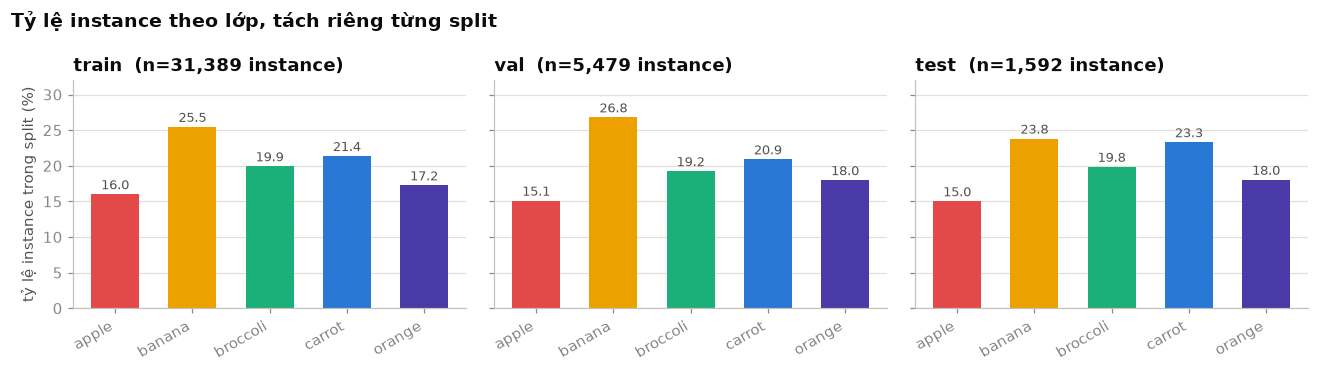

Chênh lệch tỷ lệ lớp lớn nhất, train vs val : 1.34 điểm %
Chênh lệch tỷ lệ lớp lớn nhất, train vs test: 1.94 điểm %


In [8]:
share = (
    anns_df.pivot_table(index="split", columns="class", values="ann_id",
                        aggfunc="size", fill_value=0, observed=True)
    .reindex(columns=CLASSES)
)
share_pct = share.div(share.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
x = np.arange(len(CLASSES))
for ax, split in zip(axes, SPLITS):
    vals = share_pct.loc[split].values
    ax.bar(x, vals, color=CLASS_COLORS, width=0.62)
    ax.set_xticks(x, CLASSES, rotation=30, ha="right")
    ax.set_title(f"{split}  (n={int(share.loc[split].sum()):,} instance)")
    ax.grid(axis="x", visible=False)
    ax.set_ylim(0, 32)
    for xi, v in zip(x, vals):
        ax.text(xi, v + 0.7, f"{v:.1f}", ha="center", fontsize=8.5,
                color=INK_SECONDARY)
axes[0].set_ylabel("tỷ lệ instance trong split (%)")

fig.suptitle("Tỷ lệ instance theo lớp, tách riêng từng split", x=0.005,
             ha="left", fontsize=12.5, fontweight="bold")
fig.tight_layout()
save_fig(fig, "02_class_share_by_split")
plt.show()

drift = (share_pct.loc["train"] - share_pct.loc["val"]).abs().max()
drift_test = (share_pct.loc["train"] - share_pct.loc["test"]).abs().max()
print(f"Chênh lệch tỷ lệ lớp lớn nhất, train vs val : {drift:.2f} điểm %")
print(f"Chênh lệch tỷ lệ lớp lớn nhất, train vs test: {drift_test:.2f} điểm %")

Chênh lệch train–val nhỏ vì split được chia có kiểm soát: các ảnh được nhóm theo
tổ hợp lớp xuất hiện trong ảnh, rồi mỗi nhóm mới được chia theo tỷ lệ 85/15.

Chênh lệch train–test lớn hơn một chút. Điều này là bình thường và không phải
lỗi: tập test lấy nguyên từ `val2017` của COCO, không được chọn lại, nên nó giữ
đúng phân bố gốc mà COCO cung cấp. Đây chính là lý do dùng nó làm tập đánh giá
khách quan.

## 4. Số vật thể trên mỗi ảnh

Chỉ số này cho biết bài toán nghiêng về "phát hiện" hay "đếm trong cảnh đông".

In [9]:
n_obj = images_df["n_objects"]
desc = n_obj.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print(desc.round(2).to_string())
print()
for k in (1, 2, 5, 10, 20):
    pct = 100 * (n_obj >= k).mean()
    print(f"  ảnh có >= {k:>2} vật thể: {pct:5.1f}%")

count    7137.00
mean        5.39
std         5.36
min         1.00
25%         1.00
50%         3.00
75%         8.00
90%        14.00
95%        15.00
99%        25.00
max        39.00

  ảnh có >=  1 vật thể: 100.0%
  ảnh có >=  2 vật thể:  70.7%
  ảnh có >=  5 vật thể:  41.2%
  ảnh có >= 10 vật thể:  19.4%
  ảnh có >= 20 vật thể:   2.3%


saved: eda_03_objects_per_image.png


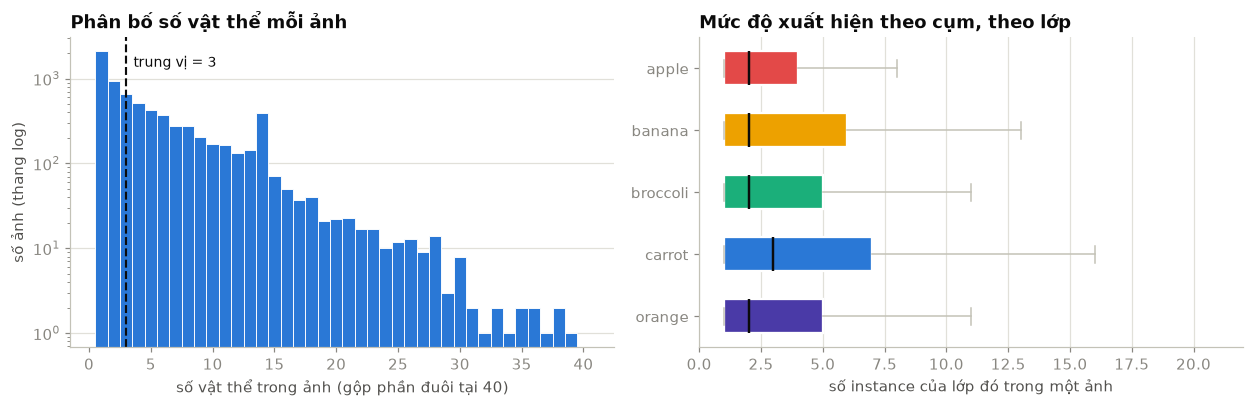

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))

ax = axes[0]
bins = np.arange(0.5, 41.5, 1)
ax.hist(n_obj.clip(upper=40), bins=bins, color=SEQUENTIAL_RAMP[7], edgecolor=SURFACE,
        linewidth=0.6)
ax.set_yscale("log")
ax.set_xlabel("số vật thể trong ảnh (gộp phần đuôi tại 40)")
ax.set_ylabel("số ảnh (thang log)")
ax.set_title("Phân bố số vật thể mỗi ảnh")
ax.grid(axis="x", visible=False)
med = n_obj.median()
ax.axvline(med, color=INK_PRIMARY, linewidth=1.4, linestyle="--")
ax.text(med + 0.6, ax.get_ylim()[1] * 0.45, f"trung vị = {med:.0f}",
        fontsize=9, color=INK_PRIMARY)

ax = axes[1]
data = [anns_df.loc[anns_df["class"] == c].groupby("image_id").size().values
        for c in CLASSES]
bp = ax.boxplot(data, **BOX_HORIZONTAL, widths=0.55, patch_artist=True,
                showfliers=False, medianprops=dict(color=INK_PRIMARY, linewidth=1.6))
for patch, color in zip(bp["boxes"], CLASS_COLORS):
    patch.set_facecolor(color)
    patch.set_edgecolor(SURFACE)
    patch.set_linewidth(1.5)
for element in ("whiskers", "caps"):
    for item in bp[element]:
        item.set_color(AXIS_LINE)
ax.set_yticks(range(1, len(CLASSES) + 1), CLASSES)
ax.invert_yaxis()
ax.set_xlabel("số instance của lớp đó trong một ảnh")
ax.set_title("Mức độ xuất hiện theo cụm, theo lớp")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, 22)

fig.tight_layout()
save_fig(fig, "03_objects_per_image")
plt.show()

Phân bố lệch phải rất mạnh: đa số ảnh có ít vật thể, nhưng có một đuôi dài các
ảnh chứa hàng chục vật thể (ví dụ một khay cà rốt thái nhỏ, một nải chuối).

Đuôi dài này là phần khó nhất của bài toán và là nơi ba model sẽ khác nhau rõ
nhất. Ảnh có 20–40 vật thể nhỏ chồng lấn đòi hỏi model phải tách được các vật
thể sát nhau; SSDlite320 với lưới anchor cố định và độ phân giải đầu vào thấp
sẽ gặp bất lợi ở đây.

## 5. Kích thước vật thể

Đây là phần phân tích quan trọng nhất đối với bài toán object detection.

Dùng hai thang đo:

- **Diện tích tuyệt đối (pixel²)** — theo đúng quy ước của COCO: `small` dưới
  32², `medium` từ 32² đến 96², `large` trên 96². `COCOeval` báo cáo AP riêng
  cho ba nhóm này, nên phân tích theo cùng cách sẽ đối chiếu được ở bước 5.
- **Diện tích tương đối (so với diện tích ảnh)** — bất biến với độ phân giải,
  cho biết vật thể chiếm bao nhiêu phần khung hình.

In [11]:
size_dist = (
    anns_df.pivot_table(index="class", columns="size_bucket", values="ann_id",
                        aggfunc="size", fill_value=0, observed=True)
    .reindex(index=CLASSES, columns=["small", "medium", "large"], fill_value=0)
)
size_pct = size_dist.div(size_dist.sum(axis=1), axis=0) * 100

overall = anns_df["size_bucket"].value_counts(normalize=True) * 100
print("Toàn bộ dataset:")
for b in ("small", "medium", "large"):
    print(f"  {b:<7} {overall.get(b, 0):5.1f}%")
print()
size_pct.round(1)

Toàn bộ dataset:
  small    25.6%
  medium   45.1%
  large    29.4%



size_bucket,small,medium,large
class,,,
apple,34.9,39.5,25.6
banana,25.1,42.0,32.8
broccoli,9.4,50.2,40.4
carrot,27.2,53.6,19.2
orange,34.1,38.4,27.5


saved: eda_04_size_buckets.png


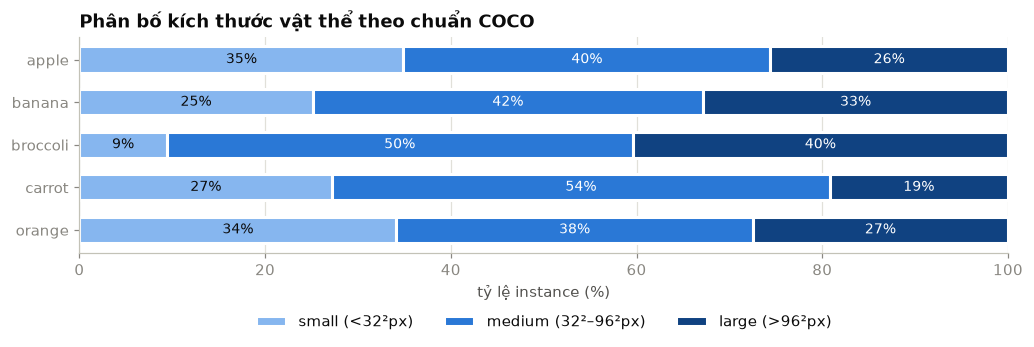

In [12]:
# small/medium/large là thang có thứ tự -> dùng một dải màu đơn sắc,
# không dùng màu theo lớp (màu theo lớp dành cho danh tính, không dành cho mức độ).
ordinal = [SEQUENTIAL_RAMP[3], SEQUENTIAL_RAMP[7], SEQUENTIAL_RAMP[11]]
labels = ["small (<32²px)", "medium (32²–96²px)", "large (>96²px)"]

fig, ax = plt.subplots(figsize=(9.5, 3.6))
y = np.arange(len(CLASSES))
left = np.zeros(len(CLASSES))
for bucket, color, label in zip(["small", "medium", "large"], ordinal, labels):
    vals = size_pct[bucket].values
    ax.barh(y, vals, left=left, height=0.62, color=color, label=label,
            edgecolor=SURFACE, linewidth=2)  # khe 2px giữa các đoạn
    for yi, (v, l) in enumerate(zip(vals, left)):
        if v >= 6:
            ax.text(l + v / 2, yi, f"{v:.0f}%", ha="center", va="center",
                    fontsize=9, color="white" if color != ordinal[0] else INK_PRIMARY)
    left += vals

ax.set_yticks(y, CLASSES)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("tỷ lệ instance (%)")
ax.set_title("Phân bố kích thước vật thể theo chuẩn COCO")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.42), ncol=3)
fig.tight_layout()
save_fig(fig, "04_size_buckets")
plt.show()

saved: eda_05_relative_size_ecdf.png


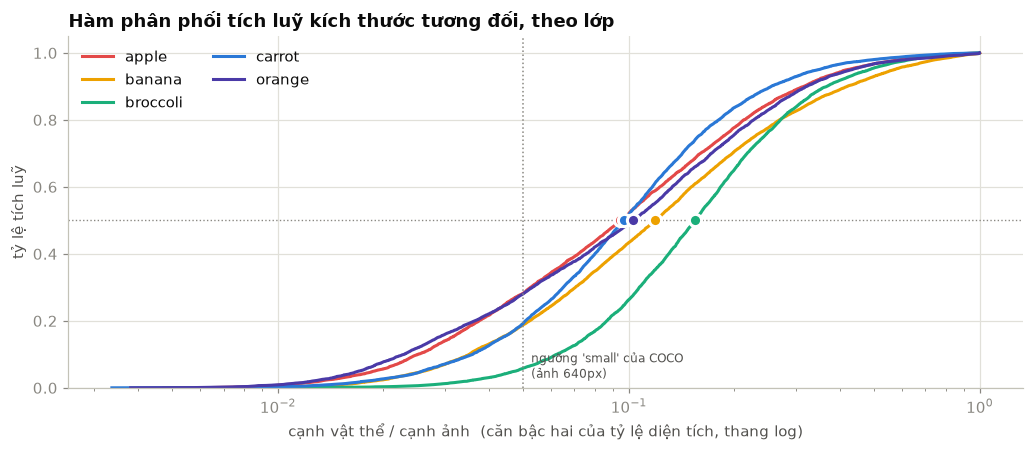

             10%     50%     90%
class                           
apple     0.0251  0.0947  0.3152
banana    0.0351  0.1188  0.4189
broccoli  0.0623  0.1545  0.3675
carrot    0.0359  0.0971  0.2548
orange    0.0229  0.1031  0.3219


In [13]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))

# Mọi đường ECDF đều hội tụ về (max, 1.0) nên không thể ghi nhãn ở cuối đường
# mà không chồng chữ. Thay vào đó ghi nhãn tại điểm trung vị, nơi các đường
# tách nhau rõ nhất.
for c, color in zip(CLASSES, CLASS_COLORS):
    v = np.sort(anns_df.loc[anns_df["class"] == c, "rel_size"].values)
    ecdf = np.arange(1, len(v) + 1) / len(v)
    ax.plot(v, ecdf, color=color, linewidth=2, label=c)

ax.set_xscale("log")
ax.set_xlabel("cạnh vật thể / cạnh ảnh  (căn bậc hai của tỷ lệ diện tích, thang log)")
ax.set_ylabel("tỷ lệ tích luỹ")
ax.set_title("Hàm phân phối tích luỹ kích thước tương đối, theo lớp")
ax.set_ylim(0, 1.05)
ax.axvline(32 / 640, color=INK_MUTED, linewidth=1, linestyle=":")
ax.text(32 / 640, 0.03, "  ngưỡng 'small' của COCO\n  (ảnh 640px)", fontsize=8,
        color=INK_SECONDARY)

# Nhãn trực tiếp tại đường trung vị: đây là chỗ 5 đường tách xa nhau nhất.
ax.axhline(0.5, color=INK_MUTED, linewidth=0.9, linestyle=":")
for c, color in zip(CLASSES, CLASS_COLORS):
    v = anns_df.loc[anns_df["class"] == c, "rel_size"]
    ax.plot([v.median()], [0.5], marker="o", markersize=8, color=color,
            markeredgecolor=SURFACE, markeredgewidth=2, zorder=5)

ax.legend(loc="upper left", ncol=2)
fig.tight_layout()
save_fig(fig, "05_relative_size_ecdf")
plt.show()

print(anns_df.groupby("class")["rel_size"].describe(
    percentiles=[0.1, 0.5, 0.9])[["10%", "50%", "90%"]].round(4).to_string())

Đây là kết quả có ảnh hưởng lớn nhất tới việc so sánh model.

Cách đọc biểu đồ ECDF: đường nằm càng lệch về bên trái thì lớp đó càng có nhiều
vật thể nhỏ. Giá trị trên trục hoành là tỷ lệ cạnh vật thể so với cạnh ảnh, ví
dụ 0.1 nghĩa là vật thể chiếm khoảng 1/10 chiều rộng khung hình.

Hàm ý cho ba model:

- **SSDlite320** resize ảnh về 320×320. Một vật thể chiếm 5% cạnh ảnh gốc sẽ chỉ
  còn khoảng 16 pixel sau khi resize. Feature map nông nhất của SSDlite có
  stride 16, nên vật thể đó chỉ còn khoảng 1 ô lưới. Dự đoán: AP_small của
  SSDlite sẽ thấp rõ rệt.
- **D-FINE-N** dùng 640×640 và có hybrid encoder đa tầng, nhưng chỉ 3 tầng
  decoder và `d_model=128` — dung lượng rất nhỏ để mô hình hoá vật thể nhỏ.
- **YOLOv8m** cũng dùng 640×640 và có cấu trúc PAN-FPN, giữ được nhiều thông tin
  ở tầng phân giải cao hơn, đồng thời có dung lượng lớn nhất trong ba model.

Vì vậy khi báo cáo kết quả, cần tách riêng AP_small / AP_medium / AP_large chứ
không chỉ nêu mAP tổng. Nếu chỉ nêu mAP tổng thì sẽ không giải thích được vì sao
các model chênh nhau.

## 6. Tỷ lệ khung của bounding box

Tỷ lệ rộng/cao ảnh hưởng tới thiết kế anchor. SSD dùng tập anchor cố định với
các tỷ lệ định sẵn (thường là 1:1, 1:2, 2:1, 1:3, 3:1). Nếu dữ liệu có nhiều
vật thể nằm ngoài các tỷ lệ này thì SSD sẽ khớp anchor kém.

saved: eda_06_aspect_ratio.png


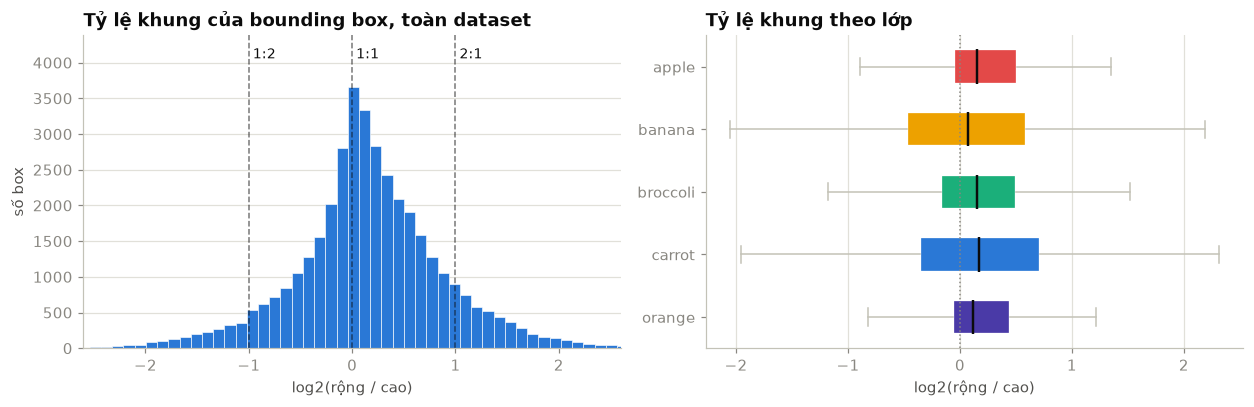

Tỷ lệ box nằm trong khoảng 1:3 đến 3:1 : 95.1%


In [14]:
log_aspect = np.log2(anns_df["aspect"].clip(0.05, 20))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))

ax = axes[0]
ax.hist(log_aspect, bins=70, color=SEQUENTIAL_RAMP[7], edgecolor=SURFACE,
        linewidth=0.4)
# Nới trần trục y trước, để nhãn tỷ lệ không đè lên cột cao nhất (nằm ngay tại 1:1).
ax.set_ylim(top=ax.get_ylim()[1] * 1.14)
for pos, lab in [(-1, "1:2"), (0, "1:1"), (1, "2:1")]:
    ax.axvline(pos, color=INK_PRIMARY, linewidth=1, linestyle="--", alpha=0.55)
    ax.text(pos, ax.get_ylim()[1] * 0.96, f" {lab}", fontsize=9, va="top",
            color=INK_PRIMARY)
ax.set_xlabel("log2(rộng / cao)")
ax.set_ylabel("số box")
ax.set_title("Tỷ lệ khung của bounding box, toàn dataset")
ax.grid(axis="x", visible=False)
ax.set_xlim(-2.6, 2.6)

ax = axes[1]
data = [np.log2(anns_df.loc[anns_df["class"] == c, "aspect"].clip(0.05, 20))
        for c in CLASSES]
bp = ax.boxplot(data, **BOX_HORIZONTAL, widths=0.55, patch_artist=True,
                showfliers=False,
                medianprops=dict(color=INK_PRIMARY, linewidth=1.6))
for patch, color in zip(bp["boxes"], CLASS_COLORS):
    patch.set_facecolor(color)
    patch.set_edgecolor(SURFACE)
    patch.set_linewidth(1.5)
for element in ("whiskers", "caps"):
    for item in bp[element]:
        item.set_color(AXIS_LINE)
ax.axvline(0, color=INK_MUTED, linewidth=1, linestyle=":")
ax.set_yticks(range(1, len(CLASSES) + 1), CLASSES)
ax.invert_yaxis()
ax.set_xlabel("log2(rộng / cao)")
ax.set_title("Tỷ lệ khung theo lớp")
ax.grid(axis="y", visible=False)

fig.tight_layout()
save_fig(fig, "06_aspect_ratio")
plt.show()

within = ((anns_df["aspect"] >= 1/3) & (anns_df["aspect"] <= 3)).mean() * 100
print(f"Tỷ lệ box nằm trong khoảng 1:3 đến 3:1 : {within:.1f}%")

## 7. Kích thước ảnh gốc

Cần biết để chọn kích thước đầu vào khi huấn luyện, và để hiểu ảnh hưởng của
việc resize.

saved: eda_07_image_sizes.png


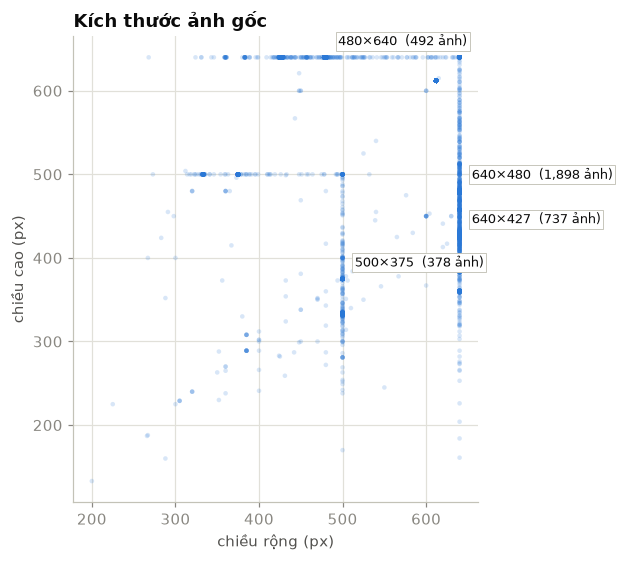

5 kích thước ảnh phổ biến nhất:
img_w  img_h
640    480      26.6
       427      10.3
480    640       6.9
500    375       5.3
612    612       4.8

Cạnh dài trung vị : 640 px
Cạnh ngắn trung vị: 458 px


In [15]:
fig, ax = plt.subplots(figsize=(6.4, 5.2))
ax.scatter(images_df["img_w"], images_df["img_h"], s=9, alpha=0.18,
           color=SEQUENTIAL_RAMP[7], edgecolors="none")
ax.set_xlabel("chiều rộng (px)")
ax.set_ylabel("chiều cao (px)")
ax.set_title("Kích thước ảnh gốc")
ax.set_aspect("equal", adjustable="box")

top = images_df.groupby(["img_w", "img_h"]).size().sort_values(ascending=False)
for (w, h), n in top.head(4).items():
    ax.annotate(f"{w}×{h}  ({n:,} ảnh)", (w, h),
                textcoords="offset points", xytext=(8, 8), fontsize=8.5,
                color=INK_PRIMARY,
                bbox=dict(facecolor=SURFACE, edgecolor=AXIS_LINE, pad=1.6,
                          linewidth=0.6))
fig.tight_layout()
save_fig(fig, "07_image_sizes")
plt.show()

print("5 kích thước ảnh phổ biến nhất:")
print((top.head(5) / len(images_df) * 100).round(1).to_string())
print(f"\nCạnh dài trung vị : {images_df[['img_w','img_h']].max(axis=1).median():.0f} px")
print(f"Cạnh ngắn trung vị: {images_df[['img_w','img_h']].min(axis=1).median():.0f} px")

## 8. Ảnh chứa nhiều lớp cùng lúc

Ảnh có nhiều lớp khó hơn ảnh một lớp, vì model phải phân biệt giữa các loại chứ
không chỉ phát hiện có hay không có vật thể.

In [16]:
nc = images_df["n_classes"].value_counts().sort_index()
nc_pct = (nc / nc.sum() * 100).round(1)
print("Số lớp khác nhau trong một ảnh:")
for k, v in nc.items():
    print(f"  {k} lớp: {v:>5,} ảnh  ({nc_pct[k]:>4.1f}%)")
print(f"\nTỷ lệ ảnh có từ 2 lớp trở lên: {100 * (images_df['n_classes'] >= 2).mean():.1f}%")

Số lớp khác nhau trong một ảnh:
  1 lớp: 5,207 ảnh  (73.0%)
  2 lớp: 1,488 ảnh  (20.8%)
  3 lớp:   390 ảnh  ( 5.5%)
  4 lớp:    47 ảnh  ( 0.7%)
  5 lớp:     5 ảnh  ( 0.1%)

Tỷ lệ ảnh có từ 2 lớp trở lên: 27.0%


saved: eda_08_multiclass_cooccurrence.png


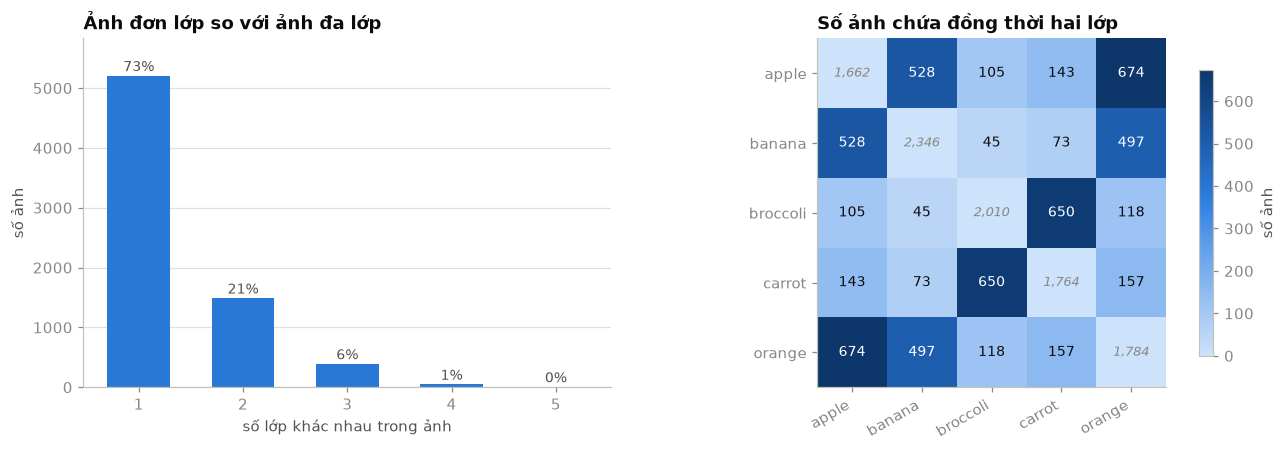

In [17]:
co = cooccurrence(anns_df, CLASSES)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2),
                         gridspec_kw={"width_ratios": [1, 1.25]})

ax = axes[0]
ax.bar(nc.index, nc.values, color=SEQUENTIAL_RAMP[7], width=0.6)
ax.set_xlabel("số lớp khác nhau trong ảnh")
ax.set_ylabel("số ảnh")
ax.set_title("Ảnh đơn lớp so với ảnh đa lớp")
ax.grid(axis="x", visible=False)
for k, v in nc.items():
    ax.text(k, v + nc.max() * 0.015, f"{nc_pct[k]:.0f}%", ha="center",
            fontsize=9, color=INK_SECONDARY)
ax.set_ylim(0, nc.max() * 1.12)

ax = axes[1]
# Ma trận là dữ liệu độ lớn -> dải màu đơn sắc, không dùng rainbow.
cmap = mpl.colors.LinearSegmentedColormap.from_list("seq", SEQUENTIAL_RAMP)
norm = mpl.colors.Normalize(vmin=0, vmax=np.triu(co.values, 1).max())
off = co.values.copy()
np.fill_diagonal(off, 0)
im = ax.imshow(off, cmap=cmap, norm=norm)
ax.set_xticks(range(len(CLASSES)), CLASSES, rotation=30, ha="right")
ax.set_yticks(range(len(CLASSES)), CLASSES)
ax.set_title("Số ảnh chứa đồng thời hai lớp")
ax.grid(False)
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        if i == j:
            ax.text(j, i, f"{co.values[i, i]:,}", ha="center", va="center",
                    fontsize=8.5, color=INK_MUTED, style="italic")
        else:
            val = off[i, j]
            ax.text(j, i, f"{val:,}", ha="center", va="center", fontsize=9,
                    color="white" if norm(val) > 0.55 else INK_PRIMARY)
fig.colorbar(im, ax=ax, shrink=0.82, label="số ảnh")

fig.tight_layout()
save_fig(fig, "08_multiclass_cooccurrence")
plt.show()

Giá trị in nghiêng trên đường chéo là tổng số ảnh chứa lớp đó, để tiện đối chiếu
với các ô ngoài đường chéo.

## 9. Mức độ chồng lấn giữa các vật thể

Với mỗi ảnh, tính IoU lớn nhất giữa hai bounding box bất kỳ trong ảnh đó. Chỉ số
này đo mức độ chen chúc của cảnh.

Ý nghĩa: bước NMS loại bỏ các box trùng nhau dựa trên ngưỡng IoU, thường là 0.5–0.7.
Nếu trong ảnh có hai vật thể thật sự chồng lấn nhau với IoU cao hơn ngưỡng đó,
NMS sẽ xoá mất một vật thể đúng, làm giảm recall. Đây là giới hạn cố hữu của
các model dùng NMS như SSDlite và YOLOv8. D-FINE không dùng NMS mà dùng cơ chế
so khớp một-một, nên về lý thuyết ít bị ảnh hưởng hơn.

In [18]:
max_iou = pairwise_iou_per_image(anns_df)
print(f"Số ảnh có từ 2 vật thể trở lên: {len(max_iou):,}")
print(max_iou.describe(percentiles=[0.5, 0.75, 0.9, 0.95]).round(3).to_string())
print()
for thr in (0.3, 0.5, 0.7):
    print(f"  ảnh có 2 vật thể thật chồng lấn IoU > {thr}: "
          f"{100 * (max_iou > thr).mean():5.1f}%")

Số ảnh có từ 2 vật thể trở lên: 5,043
count    5043.000
mean        0.185
std         0.170
min         0.000
50%         0.150
75%         0.268
90%         0.405
95%         0.504
max         0.979

  ảnh có 2 vật thể thật chồng lấn IoU > 0.3:  19.9%
  ảnh có 2 vật thể thật chồng lấn IoU > 0.5:   5.1%
  ảnh có 2 vật thể thật chồng lấn IoU > 0.7:   1.6%


saved: eda_09_overlap_iou.png


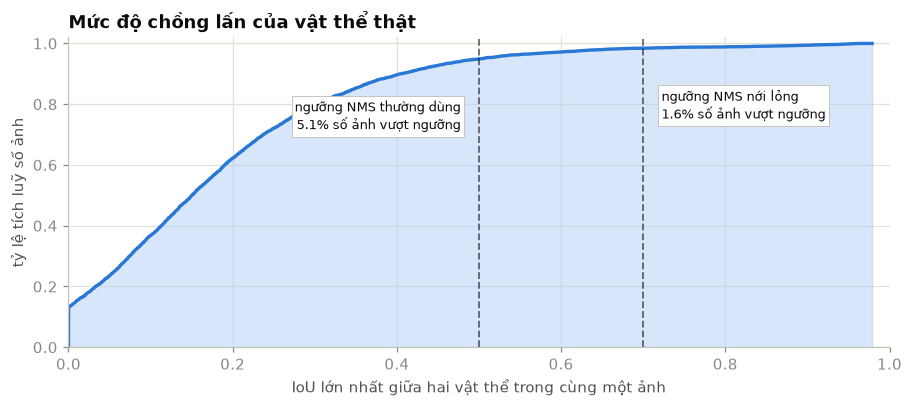

In [19]:
fig, ax = plt.subplots(figsize=(8.4, 3.8))
v = np.sort(max_iou.values)
ecdf = np.arange(1, len(v) + 1) / len(v)
ax.plot(v, ecdf, color=SEQUENTIAL_RAMP[7], linewidth=2.2)
ax.fill_between(v, ecdf, color=SEQUENTIAL_RAMP[1], alpha=0.55)

# Hai nhãn đặt về hai phía khác nhau để không đè lên nhau.
for thr, label, dx, ha in [
    (0.5, "ngưỡng NMS thường dùng", -12, "right"),
    (0.7, "ngưỡng NMS nới lỏng", 12, "left"),
]:
    frac = (max_iou > thr).mean()
    ax.axvline(thr, color=INK_PRIMARY, linestyle="--", linewidth=1.2, alpha=0.6)
    ax.annotate(f"{label}\n{frac*100:.1f}% số ảnh vượt ngưỡng",
                (thr, 1 - frac), textcoords="offset points", xytext=(dx, -46),
                ha=ha, fontsize=8.5, color=INK_PRIMARY,
                bbox=dict(facecolor=SURFACE, edgecolor=AXIS_LINE, pad=2,
                          linewidth=0.6))

ax.set_xlabel("IoU lớn nhất giữa hai vật thể trong cùng một ảnh")
ax.set_ylabel("tỷ lệ tích luỹ số ảnh")
ax.set_title("Mức độ chồng lấn của vật thể thật")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
fig.tight_layout()
save_fig(fig, "09_overlap_iou")
plt.show()

## 10. Vị trí vật thể trong khung hình

Kiểm tra xem dữ liệu có thiên lệch vị trí không. Nếu vật thể luôn nằm giữa ảnh,
model có thể học tắt theo vị trí thay vì theo đặc trưng hình ảnh, và sẽ hoạt
động kém khi triển khai thực tế với bố cục camera khác.

saved: eda_10_position_and_scale.png


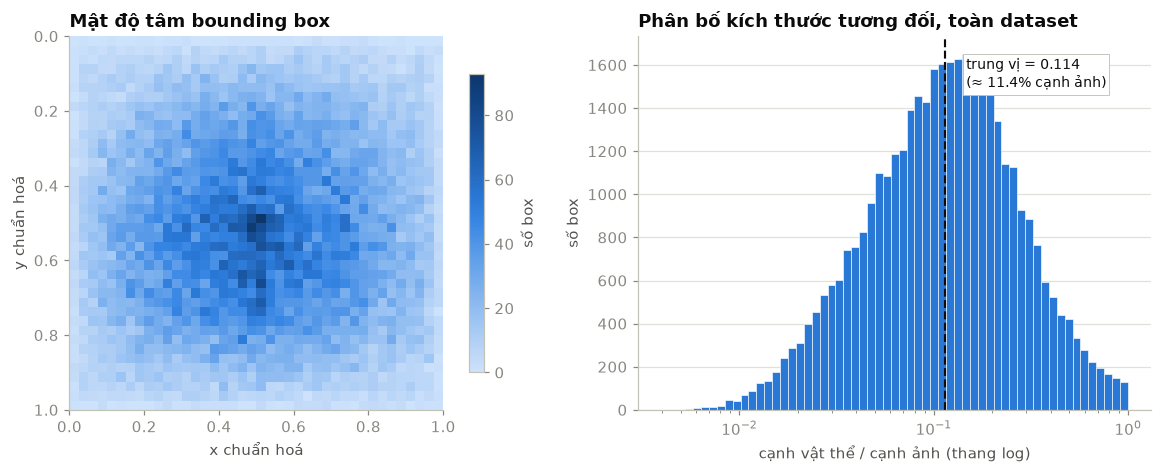

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
cmap = mpl.colors.LinearSegmentedColormap.from_list("seq", SEQUENTIAL_RAMP)

ax = axes[0]
h = ax.hist2d(anns_df["cx_norm"], anns_df["cy_norm"], bins=40,
              range=[[0, 1], [0, 1]], cmap=cmap)
ax.set_title("Mật độ tâm bounding box")
ax.set_xlabel("x chuẩn hoá")
ax.set_ylabel("y chuẩn hoá")
ax.invert_yaxis()
ax.grid(False)
ax.set_aspect("equal")
fig.colorbar(h[3], ax=ax, shrink=0.8, label="số box")

ax = axes[1]
ax.hist(anns_df["rel_size"], bins=np.logspace(-2.4, 0, 60),
        color=SEQUENTIAL_RAMP[7], edgecolor=SURFACE, linewidth=0.4)
ax.set_xscale("log")
ax.set_xlabel("cạnh vật thể / cạnh ảnh (thang log)")
ax.set_ylabel("số box")
ax.set_title("Phân bố kích thước tương đối, toàn dataset")
ax.grid(axis="x", visible=False)
median_rel = anns_df["rel_size"].median()
ax.axvline(median_rel, color=INK_PRIMARY, linestyle="--", linewidth=1.4)
# Trung vị trùng đúng đỉnh phân bố, nên nhãn phải đặt lệch sang phải để không
# đè lên các cột cao nhất.
ax.annotate(f"trung vị = {median_rel:.3f}\n(≈ {median_rel*100:.1f}% cạnh ảnh)",
            (median_rel, ax.get_ylim()[1] * 0.97),
            textcoords="offset points", xytext=(14, -6), ha="left", va="top",
            fontsize=9, color=INK_PRIMARY,
            bbox=dict(facecolor=SURFACE, edgecolor=AXIS_LINE, pad=2,
                      linewidth=0.6))

fig.tight_layout()
save_fig(fig, "10_position_and_scale")
plt.show()

## 11. Nhãn iscrowd

COCO đánh dấu `iscrowd=1` cho các vùng chứa nhiều vật thể cùng loại được gộp
thành một box duy nhất, ví dụ một đống cam trong sạp hàng.

Cách xử lý trong dự án này:

- **Giữ trong file COCO JSON**: `COCOeval` hiểu nhãn này và tự động bỏ qua khi
  tính điểm, nên giữ lại là đúng chuẩn đánh giá.
- **Loại khỏi file nhãn YOLO**: ultralytics không có khái niệm `iscrowd`. Nếu
  giữ lại, model sẽ học rằng cả một đống cam là một vật thể duy nhất, làm hỏng
  việc đếm.

In [21]:
crowd = anns_df.groupby("class")["iscrowd"].agg(["sum", "size"]).reindex(CLASSES)
crowd.columns = ["so_box_iscrowd", "tong_box"]
crowd["ty_le_%"] = (100 * crowd["so_box_iscrowd"] / crowd["tong_box"]).round(2)
print(crowd.to_string())
print(f"\nTổng số box iscrowd: {int(anns_df['iscrowd'].sum()):,} "
      f"({100 * anns_df['iscrowd'].mean():.2f}% tổng số box)")

crowd_area = anns_df.groupby("iscrowd")["rel_size"].median()
print("\nKích thước tương đối trung vị:")
print(f"  box thường  : {crowd_area.get(0, float('nan')):.3f}")
print(f"  box iscrowd : {crowd_area.get(1, float('nan')):.3f}")

          so_box_iscrowd  tong_box  ty_le_%
class                                      
apple                 78      6090     1.28
banana               272      9837     2.77
broccoli              51      7624     0.67
carrot               100      8223     1.22
orange                99      6686     1.48

Tổng số box iscrowd: 600 (1.56% tổng số box)

Kích thước tương đối trung vị:
  box thường  : 0.112
  box iscrowd : 0.571


## 12. Tổng hợp và hàm ý cho bước huấn luyện

Phần này tóm tắt các số liệu đã tính và ghi lại thành file để dùng cho báo cáo.

In [22]:
import json

summary = {
    "tong_quan": {
        "so_anh": int(len(images_df)),
        "so_instance": int(len(anns_df)),
        "so_lop": len(CLASSES),
        "vat_the_tren_anh_tb": round(float(images_df["n_objects"].mean()), 2),
        "vat_the_tren_anh_trung_vi": int(images_df["n_objects"].median()),
    },
    "theo_split": {
        s: {
            "so_anh": int((images_df["split"] == s).sum()),
            "so_instance": int((anns_df["split"] == s).sum()),
        } for s in SPLITS
    },
    "can_bang_lop": {
        "ty_le_mat_can_bang": round(float(imbalance), 2),
        "instance_theo_lop": {k: int(v) for k, v in inst_per_class.items()},
        "drift_train_val_diem_%": round(float(drift), 2),
        "drift_train_test_diem_%": round(float(drift_test), 2),
    },
    "kich_thuoc": {
        "phan_bo_coco_%": {k: round(float(v), 1) for k, v in overall.items()},
        "rel_size_trung_vi": round(float(anns_df["rel_size"].median()), 4),
        "ty_le_box_trong_1_3_den_3_1_%": round(float(within), 1),
    },
    "do_kho": {
        "ty_le_anh_da_lop_%": round(float(100 * (images_df["n_classes"] >= 2).mean()), 1),
        "max_iou_trung_vi": round(float(max_iou.median()), 3),
        "ty_le_anh_iou_tren_0_5_%": round(float(100 * (max_iou > 0.5).mean()), 1),
    },
}

path = RESULTS_DIR / "eda_summary.json"
path.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")
print("Đã ghi:", path)
print(json.dumps(summary, indent=2, ensure_ascii=False))

Đã ghi: C:\Users\KUONG\Desktop\final-object-detection\reports\results\eda_summary.json
{
  "tong_quan": {
    "so_anh": 7137,
    "so_instance": 38460,
    "so_lop": 5,
    "vat_the_tren_anh_tb": 5.39,
    "vat_the_tren_anh_trung_vi": 3
  },
  "theo_split": {
    "train": {
      "so_anh": 5803,
      "so_instance": 31389
    },
    "val": {
      "so_anh": 1024,
      "so_instance": 5479
    },
    "test": {
      "so_anh": 310,
      "so_instance": 1592
    }
  },
  "can_bang_lop": {
    "ty_le_mat_can_bang": 1.62,
    "instance_theo_lop": {
      "apple": 6090,
      "banana": 9837,
      "broccoli": 7624,
      "carrot": 8223,
      "orange": 6686
    },
    "drift_train_val_diem_%": 1.34,
    "drift_train_test_diem_%": 1.94
  },
  "kich_thuoc": {
    "phan_bo_coco_%": {
      "medium": 45.1,
      "large": 29.4,
      "small": 25.6
    },
    "rel_size_trung_vi": 0.1142,
    "ty_le_box_trong_1_3_den_3_1_%": 95.1
  },
  "do_kho": {
    "ty_le_anh_da_lop_%": 27.0,
    "max_iou_trung

### Kết luận

**Về chất lượng dữ liệu**

Dataset đủ điều kiện để huấn luyện và so sánh model một cách có ý nghĩa. Mất cân
bằng lớp ở mức nhẹ, phân bố lớp giữa train và val gần như trùng nhau, và tập
test hoàn toàn tách biệt về nguồn gốc.

Giới hạn cần nêu trong báo cáo: tập test chỉ có 310 ảnh và 1.592 instance. Với
quy mô này, chênh lệch mAP nhỏ hơn khoảng 1–2 điểm giữa hai model không đủ cơ
sở để kết luận model nào tốt hơn.

**Về độ khó của bài toán**

Ba yếu tố làm bài toán khó hơn mức trung bình:

1. Vật thể nhỏ chiếm tỷ trọng lớn. Đây sẽ là yếu tố phân hoá ba model rõ nhất.
2. Mật độ vật thể cao, trung bình hơn 5 vật thể mỗi ảnh, có ảnh lên tới vài chục.
3. Vật thể cùng loại thường chồng lấn nhau, gây khó cho bước NMS.

**Hàm ý cho thiết kế thí nghiệm ở bước 4 và 5**

- Phải báo cáo AP tách theo nhóm kích thước (`AP_small`, `AP_medium`, `AP_large`),
  không chỉ mAP tổng. Nếu chỉ có mAP tổng thì không giải thích được nguyên nhân
  chênh lệch giữa các model.
- Nên báo cáo mAP theo từng lớp, vì độ khó của các lớp không giống nhau.
- Khi so sánh tốc độ, phải nêu rõ kích thước ảnh đầu vào của từng model.
  SSDlite320 chạy ở 320×320 còn D-FINE-N và YOLOv8m ở 640×640, nên so sánh FPS
  trực tiếp mà không nói rõ điều này là không công bằng.
- Ba model chênh nhau **11,4 lần về số tham số** (2,26M / 3,72M / 25,86M), nên
  không được kết luận "hướng nào yếu hơn" từ điểm số thô. Trục so sánh hợp lệ
  là hiệu quả: mAP trên mỗi tham số, mỗi mili-giây.
- Dự đoán trước khi chạy thí nghiệm: SSDlite320 sẽ có FPS cao nhất nhưng
  AP_small thấp nhất; YOLOv8m sẽ cân bằng nhất giữa tốc độ và độ chính xác;
  D-FINE-N sẽ có lợi thế ở các ảnh chồng lấn vì không dùng NMS, nhưng cần nhiều
  epoch hơn để hội tụ. Ghi lại dự đoán này để đối chiếu ở bước 5.